In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df1 = pd.read_excel(r"C:\Users\rusha\credits.xlsx")
df2 = pd.read_excel(r"C:\Users\rusha\titles.xlsx")


In [11]:
df1.head()
df2.head()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts300399,Five Came Back: The Reference Films,SHOW,This collection includes 12 World War II-era p...,1945,TV-MA,51,['documentation'],['US'],1.0,NaN,NaN,NaN,0.600,NaN
1,tm84618,Taxi Driver,MOVIE,A mentally unstable Vietnam War veteran works ...,1976,R,114,"['drama', 'crime']",['US'],NaN,tt0075314,8.2,808582.0,40.965,8.179
2,tm154986,Deliverance,MOVIE,Intent on seeing the Cahulawassee River before...,1972,R,109,"['drama', 'action', 'thriller', 'european']",['US'],NaN,tt0068473,7.7,107673.0,10.010,7.300
3,tm127384,Monty Python and the Holy Grail,MOVIE,"King Arthur, accompanied by his squire, recrui...",1975,PG,91,"['fantasy', 'action', 'comedy']",['GB'],NaN,tt0071853,8.2,534486.0,15.461,7.811
4,tm120801,The Dirty Dozen,MOVIE,12 American military prisoners in World War II...,1967,NaN,150,"['war', 'action']","['GB', 'US']",NaN,tt0061578,7.7,72662.0,20.398,7.600


In [13]:
df1.info()
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77801 entries, 0 to 77800
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   person_id  77801 non-null  int64 
 1   id         77801 non-null  object
 2   name       77801 non-null  object
 3   character  68029 non-null  object
 4   role       77801 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.0+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5850 entries, 0 to 5849
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    5850 non-null   object 
 1   title                 5849 non-null   object 
 2   type                  5850 non-null   object 
 3   description           5832 non-null   object 
 4   release_year          5850 non-null   int64  
 5   age_certification     3231 non-null   object 
 6   runtime               5850 non-null   int64  
 7 

In [17]:
df1.columns
df2.columns

Index(['id', 'title', 'type', 'description', 'release_year',
       'age_certification', 'runtime', 'genres', 'production_countries',
       'seasons', 'imdb_id', 'imdb_score', 'imdb_votes', 'tmdb_popularity',
       'tmdb_score'],
      dtype='object')

In [19]:
df = pd.merge(df1, df2, on="id", how="inner")
df.head()

,person_id,id,name,character,role,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,3748,tm84618,Robert De Niro,Travis Bickle,ACTOR,Taxi Driver,MOVIE,A mentally unstable Vietnam War veteran works ...,1976,R,114,"['drama', 'crime']",['US'],NaN,tt0075314,8.2,808582.0,40.965,8.179
1,14658,tm84618,Jodie Foster,Iris Steensma,ACTOR,Taxi Driver,MOVIE,A mentally unstable Vietnam War veteran works ...,1976,R,114,"['drama', 'crime']",['US'],NaN,tt0075314,8.2,808582.0,40.965,8.179
2,7064,tm84618,Albert Brooks,Tom,ACTOR,Taxi Driver,MOVIE,A mentally unstable Vietnam War veteran works ...,1976,R,114,"['drama', 'crime']",['US'],NaN,tt0075314,8.2,808582.0,40.965,8.179
3,3739,tm84618,Harvey Keitel,Matthew 'Sport' Higgins,ACTOR,Taxi Driver,MOVIE,A mentally unstable Vietnam War veteran works ...,1976,R,114,"['drama', 'crime']",['US'],NaN,tt0075314,8.2,808582.0,40.965,8.179
4,48933,tm84618,Cybill Shepherd,Betsy,ACTOR,Taxi Driver,MOVIE,A mentally unstable Vietnam War veteran works ...,1976,R,114,"['drama', 'crime']",['US'],NaN,tt0075314,8.2,808582.0,40.965,8.179


In [35]:
df.drop_duplicates(inplace=True) 
df.fillna("Unknown",inplace=True)


In [37]:
df['type'].value_counts()

type
MOVIE    63091
SHOW     14710
Name: count, dtype: int64

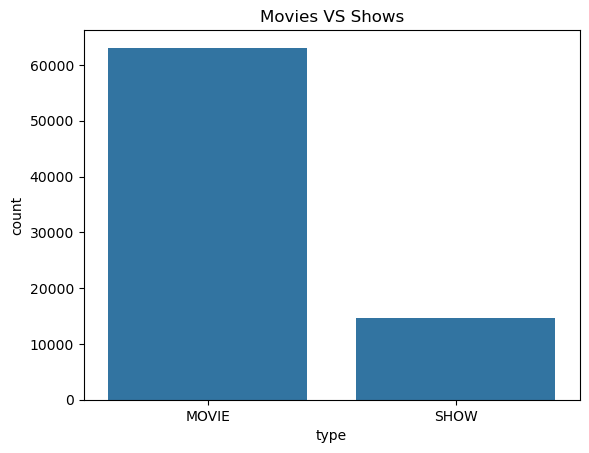

In [39]:
sns.countplot(x='type',data=df)
plt.title("Movies VS Shows")
plt.show()

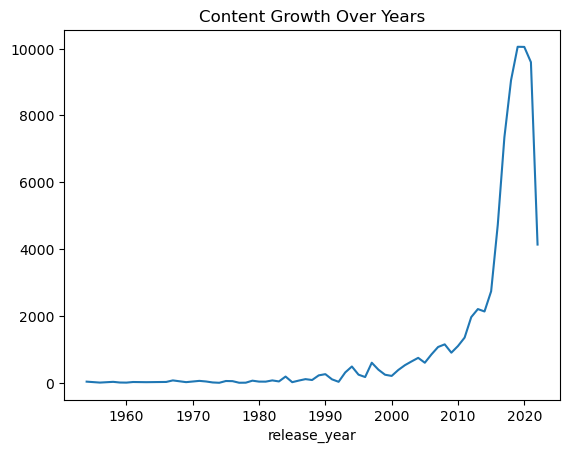

In [41]:
df['release_year'].value_counts().sort_index().plot()
plt.title("Content Growth Over Years")
plt.show()

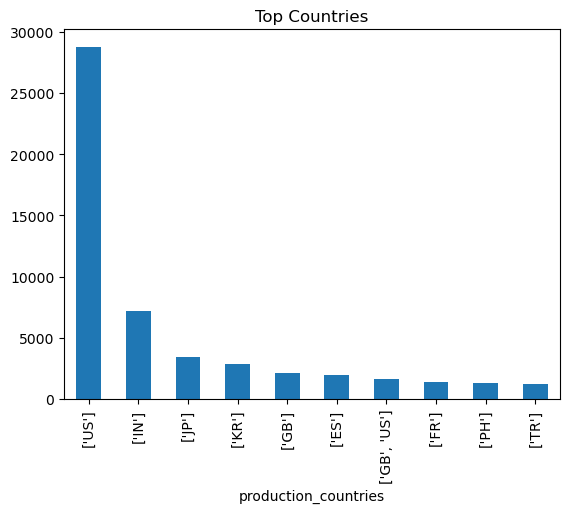

In [53]:
df['production_countries'].value_counts().head(10)
df['production_countries'].value_counts().head(10).plot(kind='bar')
plt.title("Top Countries")
plt.show()

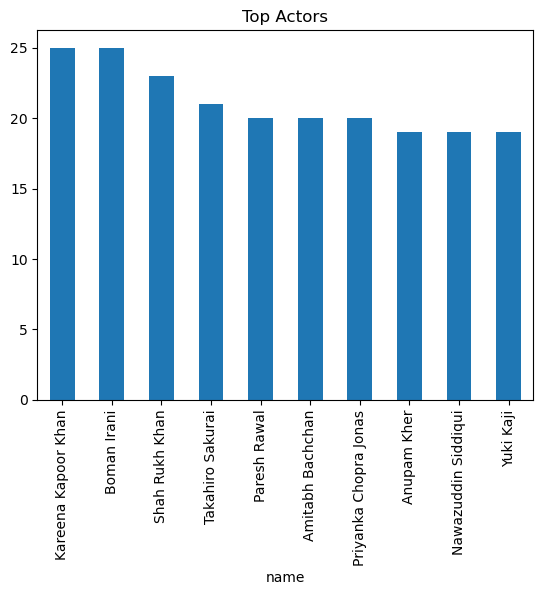

In [55]:
actors = df[df['role'] == 'ACTOR']
actors['name'].value_counts().head(10)
actors['name'].value_counts().head(10).plot(kind='bar')
plt.title("Top Actors")
plt.show()

In [74]:
df['imdb_score'].unique()

array([8.2, 7.7, 8.8, 8.0, 5.8, 7.5, 7.3, 8.1, 6.2, 7.2, 2.1, 7.6, 7.4,
       6.7, 6.1, 6.4, 5.1, 6.5, 6.6, 7.8, 4.6, 4.4, 8.9, 8.7, 8.3, 6.9,
       7.1, 4.9, 7.9, 5.9, 7.0, 6.0, 5.6, 'Unknown', 5.4, 6.3, 5.2, 3.8,
       4.8, 8.4, 8.6, 8.5, 4.5, 6.8, 9.0, 5.5, 5.0, 9.5, 9.3, 5.7, 4.0,
       3.9, 3.6, 4.1, 5.3, 4.7, 2.9, 3.4, 4.3, 2.0, 4.2, 3.2, 3.5, 1.7,
       9.2, 3.0, 3.7, 1.9, 2.8, 1.5, 2.7, 9.1, 3.3, 2.3, 3.1, 2.2, 1.6,
       2.5, 2.6], dtype=object)

In [80]:
df['imdb_score'] = df['imdb_score'].replace(['Unknown', ' '], None)

In [84]:
df['imdb_score'] = pd.to_numeric(df['imdb_score'], errors='coerce')

In [86]:
df = df.dropna(subset=['imdb_score'])

In [88]:
top_rated = df.sort_values(by='imdb_score', ascending=False).head(10)

top_rated[['title', 'imdb_score']]


,title,imdb_score
4463,Breaking Bad,9.5
4456,Breaking Bad,9.5
4462,Breaking Bad,9.5
4461,Breaking Bad,9.5
4460,Breaking Bad,9.5
4459,Breaking Bad,9.5
4458,Breaking Bad,9.5
4457,Breaking Bad,9.5
4874,Avatar: The Last Airbender,9.3
4875,Avatar: The Last Airbender,9.3
